In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from sklearn import metrics

In [ ]:
# Reading the CSV file 'SaYoPillow.csv' and storing the data in a DataFrame called 'data'
data = pd.read_csv("/content/drive/MyDrive/12 (1).csv")

# Displaying the first 5 rows of the dataset
data.head()

,sr,rr,t,lm,bo,rem,sr.1,hr,sl
0,93.80,25.680,91.840,16.600,89.840,76.09,1.840,74.20,3
1,56.09,25.104,91.552,15.880,89.552,98.88,1.552,72.76,3
2,60.00,20.000,67.000,10.000,95.000,85.00,7.000,60.00,1
3,85.76,23.536,90.768,13.920,88.768,17.90,0.768,68.84,3
4,48.12,17.248,89.450,6.496,96.248,72.48,8.248,53.12,0


In [ ]:
# Displaying the last 5 rows of the dataset
data.tail()

,sr,rr,t,lm,bo,rem,sr.1,hr,sl
633,97.504,27.504,86.880,17.752,84.256,101.88,NaN,78.760,4
634,58.640,19.728,95.728,9.728,94.592,84.32,6.728,59.320,1
635,73.920,21.392,93.392,11.392,91.392,91.96,NaN,63.480,2
636,56.670,23.564,NaN,10.540,67.230,90.78,2.867,23.766,3
637,45.546,23.784,12.567,12.540,45.640,88.90,9.000,67.343,2


In [ ]:
# Shape of our data
print("Rows and Columns of the dataset :- ",data.shape)


Rows and Columns of the dataset :-  (638, 9)


In [ ]:
# Identifying information about composition and potential data quality
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sr      638 non-null    float64
 1   rr      638 non-null    float64
 2   t       637 non-null    float64
 3   lm      638 non-null    float64
 4   bo      638 non-null    float64
 5   rem     638 non-null    float64
 6   sr.1    636 non-null    float64
 7   hr      638 non-null    float64
 8   sl      638 non-null    int64  
dtypes: float64(8), int64(1)
memory usage: 45.0 KB


In [ ]:
# Displaying the columns in our dataset
data.columns

Index(['sr', 'rr', 't', 'lm', 'bo', 'rem', 'sr.1', 'hr', 'sl'], dtype='object')

In [ ]:
# Renaming the columns of the DataFrame for better readability and understanding
data.columns=['snoring_rate', 'respiration_rate', 'body_temperature', 'limb_movement', 'blood_oxygen',
             'eye_movement', 'sleeping_hours', 'heart_rate', 'stress_level']
data.head()


,snoring_rate,respiration_rate,body_temperature,limb_movement,blood_oxygen,eye_movement,sleeping_hours,heart_rate,stress_level
0,93.80,25.680,91.840,16.600,89.840,76.09,1.840,74.20,3
1,56.09,25.104,91.552,15.880,89.552,98.88,1.552,72.76,3
2,60.00,20.000,67.000,10.000,95.000,85.00,7.000,60.00,1
3,85.76,23.536,90.768,13.920,88.768,17.90,0.768,68.84,3
4,48.12,17.248,89.450,6.496,96.248,72.48,8.248,53.12,0


In [ ]:
# To show statistical summary of the columns of our data
data.describe(include="all")



,snoring_rate,respiration_rate,body_temperature,limb_movement,blood_oxygen,eye_movement,sleeping_hours,heart_rate,stress_level
count,638.000000,638.000000,637.000000,638.000000,638.000000,638.000000,636.000000,638.000000,638.000000
mean,70.820028,21.731085,89.864969,11.672981,90.025381,86.345544,3.706763,64.082403,2.001567
std,19.896532,4.036706,12.455355,4.318693,7.473683,14.821294,3.054277,10.755625,1.412547
min,10.000000,10.766000,12.567000,1.560000,12.545000,17.900000,0.000000,12.765000,0.000000
25%,51.940000,18.452000,89.720000,8.500000,88.308000,80.370000,0.556000,56.010000,1.000000
50%,68.720000,20.984000,92.528000,11.000000,90.856000,88.320000,3.452000,62.420000,2.000000
75%,90.650000,24.904000,95.232000,15.710000,94.178000,97.950000,6.524000,72.420000,3.000000
max,100.000000,30.000000,98.976000,19.000000,97.000000,105.000000,9.000000,85.000000,4.000000


In [ ]:
#checking for null values in the dataframe
data.isnull().sum()


,0
snoring_rate,0
respiration_rate,0
body_temperature,1
limb_movement,0
blood_oxygen,0
eye_movement,0
sleeping_hours,2
heart_rate,0
stress_level,0


In [ ]:
from sklearn.preprocessing import StandardScaler
# Handle missing values
# For example, replace missing values with the mean of the column
data.fillna(data.mean(), inplace=True)
# Feature scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data.drop('stress_level', axis=1))
data_scaled = pd.DataFrame(scaled_features, columns=data.columns[:-1])


In [ ]:
#after preprocessing
data.tail()


,snoring_rate,respiration_rate,body_temperature,limb_movement,blood_oxygen,eye_movement,sleeping_hours,heart_rate,stress_level
633,97.504,27.504,86.880000,17.752,84.256,101.88,3.706763,78.760,4
634,58.640,19.728,95.728000,9.728,94.592,84.32,6.728000,59.320,1
635,73.920,21.392,93.392000,11.392,91.392,91.96,3.706763,63.480,2
636,56.670,23.564,89.864969,10.540,67.230,90.78,2.867000,23.766,3
637,45.546,23.784,12.567000,12.540,45.640,88.90,9.000000,67.343,2


In [ ]:
# To display number of samples on each class
data['stress_level'].value_counts()


,count
stress_level,
2,129
3,128
1,127
0,127
4,127


In [ ]:
X = data.drop(['stress_level'], axis=1)
y = data['stress_level']




In [ ]:
# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  random_state=42)

# Display the shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)





X_train shape: (510, 8)
y_train shape: (510,)
X_test shape: (128, 8)
y_test shape: (128,)


In [ ]:
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train,y_train)




DecisionTreeClassifier(random_state=42)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
# Train the classifier
dt_classifier.fit(X_train, y_train)
# Predictions on the test set
y_pred = dt_classifier.predict(X_test)
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
# Error rate = 1 - Accuracy
error_rate = 1 - accuracy
print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {error_rate:.2f}")

report_dt= classification_report(y_test,y_pred,zero_division=1)
print(report_dt)

Accuracy: 0.98
Error rate: 0.02
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        21
           1       1.00      0.94      0.97        31
           2       1.00      0.96      0.98        25
           3       0.96      1.00      0.98        22
           4       1.00      1.00      1.00        29

    accuracy                           0.98       128
   macro avg       0.97      0.98      0.98       128
weighted avg       0.98      0.98      0.98       128



In [ ]:
random_forest = RandomForestClassifier()
random_forest.fit(X_train,y_train)




RandomForestClassifier()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)
# Train the classifier
rf_classifier.fit(X_train, y_train)
# Predictions on the test set
y_pred = rf_classifier.predict(X_test)
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
# Error rate = 1 - Accuracy
error_rate = 1 - accuracy
print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {error_rate:.2f}")

report_rf= classification_report(y_test,y_pred,zero_division=1)
print(report_rf)

Accuracy: 0.99
Error rate: 0.01
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        31
           2       1.00      0.96      0.98        25
           3       0.96      1.00      0.98        22
           4       1.00      1.00      1.00        29

    accuracy                           0.99       128
   macro avg       0.99      0.99      0.99       128
weighted avg       0.99      0.99      0.99       128



In [ ]:
naive_bayes= GaussianNB()
naive_bayes.fit(X_train,y_train)


GaussianNB()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize Naive Bayes classifier
nb_classifier = GaussianNB()
# Train the classifier
nb_classifier.fit(X_train, y_train)
# Predictions on the test set
y_pred = nb_classifier.predict(X_test)
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
# Error rate = 1 - Accuracy
error_rate = 1 - accuracy
print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {error_rate:.2f}")

report_Gbn= classification_report(y_test,y_pred,zero_division=1)
print(report_Gbn)

Accuracy: 0.95
Error rate: 0.05
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        21
           1       1.00      0.87      0.93        31
           2       0.93      1.00      0.96        25
           3       0.91      0.95      0.93        22
           4       1.00      0.93      0.96        29

    accuracy                           0.95       128
   macro avg       0.94      0.95      0.94       128
weighted avg       0.95      0.95      0.95       128



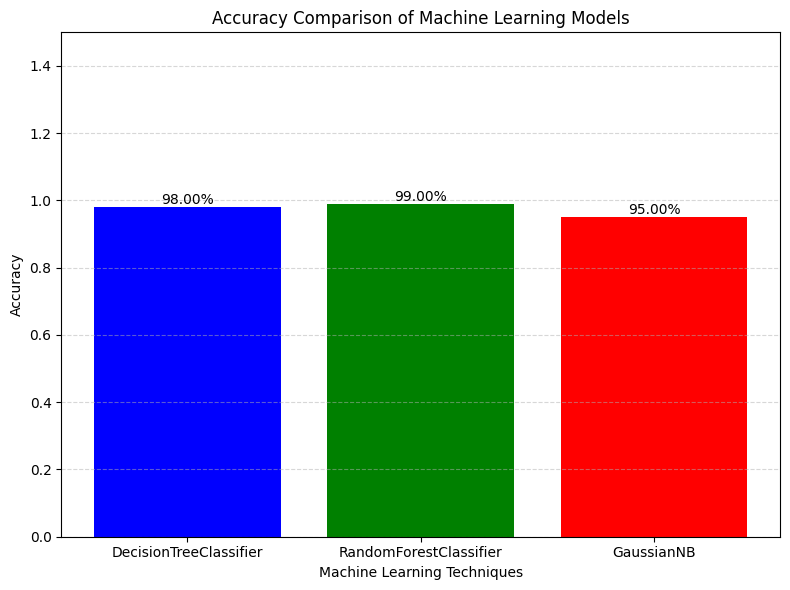

In [ ]:
import matplotlib.pyplot as plt
# Define the models and their respective accuracies
models = ['DecisionTreeClassifier', 'RandomForestClassifier', 'GaussianNB']
accuracies = [0.98, 0.99, 0.95, ]  # Replace with your actual accuracy values
# Plotting the bar chart
plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=['blue', 'green', 'red'])
# Adding titles and labels
plt.title('Accuracy Comparison of Machine Learning Models')
plt.xlabel('Machine Learning Techniques')
plt.ylabel('Accuracy')
# Display the accuracy values on top of the bars
for i in range(len(models)):
    plt.text(i, accuracies[i], f'{accuracies[i]*100:.2f}%', ha='center', va='bottom')
# Show the plot
plt.ylim(0, 1.5)  # Set the y-axis limit between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.5)  # Add gridlines
plt.tight_layout()
plt.show()

In [ ]:
new_data = pd.DataFrame([[90.0, 23.0, 92.0, 15.0, 90.0, 95.0, 2.0, 70.0]], columns=X.columns)
# Predict the stress level for the new data
predicted_stress_level = random_forest.predict(new_data)
# Dictionary to map integer stress levels to human-readable labels
stress_level_labels = {
    0: "Low/Normal",
    1: "Medium low",
    2: "Medium",
    3: "Medium High",
    4: "High"
}
if predicted_stress_level == 0:
    print("Low stress level. Keep up the good work!")
elif predicted_stress_level == 1:
    print("Medium low stress level. Try to incorporate some relaxation techniques.")
elif predicted_stress_level == 2:
    print("Medium. Consider taking a break and engaging in stress-reducing activities.")
elif predicted_stress_level == 3:
    print ("Medium high stress level. It's important to prioritize self-care and seek support.")
else:
    print("High stress level. Seek professional help and prioritize your well-being.")
predicted_stress_label = stress_level_labels[predicted_stress_level[0]]
print("Predicted Stress Label for New Data:",predicted_stress_level[0],"(",predicted_stress_label,")")







Medium high stress level. It's important to prioritize self-care and seek support.
Predicted Stress Label for New Data: 3 ( Medium High )
